# 📊 Análisis de Churn de Clientes - Telecom X

## 📌 Descripción

Proyecto de análisis de **cancelación de clientes (Churn)** en Telecom X utilizando Python.
El objetivo es explorar, limpiar y analizar los datos para identificar los factores que influyen en la pérdida de clientes y generar insights que sirvan de base para futuros **modelos predictivos y estrategias de retención**.

---

## 🎯 Objetivos

* Explorar y comprender el dataset de clientes.
* Realizar limpieza y preparación de datos.
* Analizar variables relacionadas con la cancelación de clientes.
* Identificar patrones y tendencias en el comportamiento de los usuarios.
* Generar información útil para modelos de predicción de churn.

---

## 🛠️ Tecnologías Utilizadas

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook

---

## 📂 Estructura del Proyecto

```
telecom-churn-analisis/
│
├── datos/
│   └── telecom_churn.csv
│
├── notebooks/
│   └── analisis_churn.ipynb
│
├── src/
│   └── procesamiento_datos.py
│
├── README.md
└── requirements.txt
```

---

## 📈 Análisis Realizado

Durante el proyecto se llevaron a cabo diferentes etapas del análisis de datos:

* Análisis Exploratorio de Datos (**EDA**)
* Visualización de variables relevantes
* Identificación de factores asociados al churn
* Preparación de datos para futuros modelos de **Machine Learning**

---

## 🚀 Resultados Esperados

Este análisis permitirá comprender mejor las razones por las que los clientes cancelan el servicio y proporcionará información útil para:

* Reducir la tasa de cancelación
* Mejorar la experiencia del cliente
* Apoyar el desarrollo de modelos predictivos

---

## 👤 Autor

**Starlyn Manuel Duarte Guzmán**

Interesado en **Ciencia de Datos, Ingeniería de Datos y análisis estadístico aplicado a problemas reales**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**#📌 Extracción(E - Extract)**

In [2]:
#📌 Cargar el Dataset
df = pd.read_json("/content/TelecomX_Data.json")
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


**Conociendo el conjunto de Datos**

In [3]:
# Conociendo el conjunto de Datos
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [4]:
# Normalizamos el df

df_telecomX = pd.concat([
    df[['customerID','Churn']],
    pd.json_normalize(df['customer']),
    pd.json_normalize(df['phone']),
    pd.json_normalize(df['internet']),
    pd.json_normalize(df['account'])
], axis=1)

df_telecomX.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
# Verificar el nuevo data Frame
df_telecomX.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


# **Creación de Columnas cuentas Diarias**

In [6]:
# Creación de Columnas cuentas Diarias
df_telecomX['daily_accounts'] =df_telecomX['Charges.Monthly']/30
df_telecomX.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,daily_accounts
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


**Estandarización y transformación de datos**

***Limpieza de Datos***

In [7]:
#Estandarización y transformación de datos
df_telecomX.columns = df_telecomX.columns.str.lower()
df_telecomX.columns = df_telecomX.columns.str.replace(' ','_')
df_telecomX['charges.monthly'] = pd.to_numeric(df_telecomX['charges.monthly'], errors='coerce')
df_telecomX.head()

#Convertir Yes / No a binario

df_telecomX.replace({'Yes': 1, 'No': 0}, inplace=True)
df_telecomX.head()

#7️⃣ Revisar valores faltantes
df_telecomX.isnull().sum()
df_telecomX = df_telecomX.dropna()
df_telecomX.isnull().sum()

# revisar duplicados
df_telecomX.duplicated().sum()
df_telecomX = df_telecomX.drop_duplicates()
df_telecomX.duplicated().sum()



/tmp/ipykernel_499/667337535.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telecomX.replace({'Yes': 1, 'No': 0}, inplace=True)


np.int64(0)

**Analisis descriptivo**

In [8]:
#Analisis descriptivo
df_telecomX.describe()



,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,charges.monthly,daily_accounts
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.958333


**ANÁLISIS DE DISTRIBUCIÓN DE CHURN**

In [22]:
# Distribucion de Evacion
df_telecomX['churn'].value_counts()
df_telecomX['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,71.198569
1,25.719004
,3.082427


Aquí observamos la cantidad y el porcentaje de clientes
que permanecen activos frente a los que cancelaron el servicio.

**Distribución de evasión**

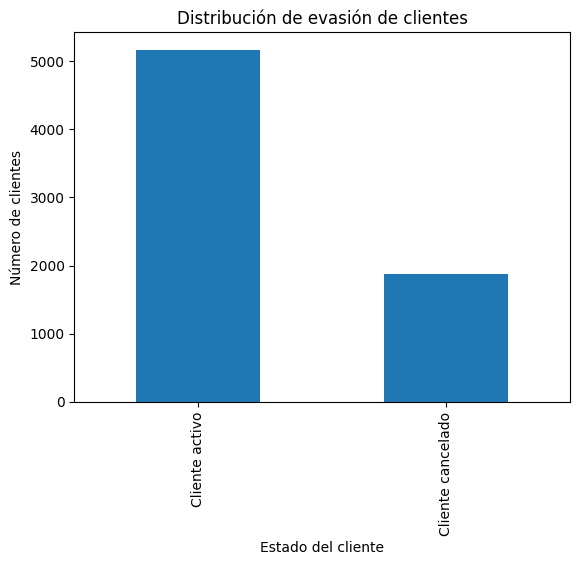

In [10]:
# Distribucion de Evacion
df_telecomX['churn'].value_counts()
df_telecomX['churn'].value_counts(normalize=True) * 100
import matplotlib.pyplot as plt

df_telecomX['EstadoCliente'] = df_telecomX['churn'].map({
    0: 'Cliente activo',
    1: 'Cliente cancelado'
})

df_telecomX['EstadoCliente'].value_counts().plot(kind='bar')

plt.title("Distribución de evasión de clientes")
plt.xlabel("Estado del cliente")
plt.ylabel("Número de clientes")

plt.show()



Los hallazgos sobre el tiempo de permanencia del cliente indican que aquellos clientes que cancelan el servicio tienden a tener una menor permanencia en la empresa. Esto sugiere que la evasión ocurre con mayor frecuencia durante los primeros meses del contrato, lo que hace que este período sea crucial para la retención de clientes

**Recuento de evasión por variables categóricas**

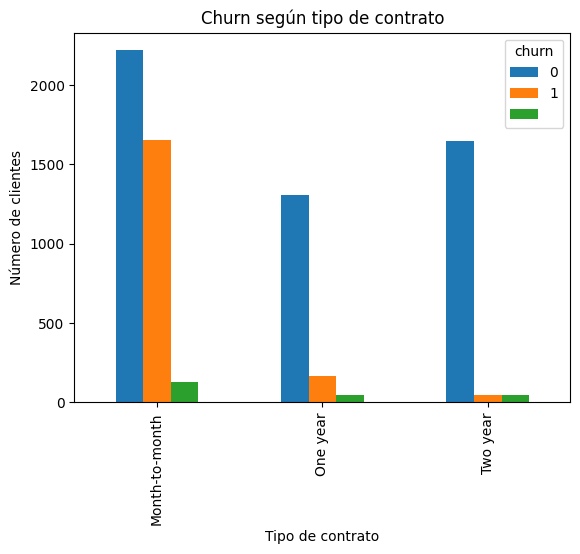

In [11]:
#Churn por tipo de contrato

pd.crosstab(df_telecomX['contract'], df_telecomX['churn'], normalize='index')*100
pd.crosstab(df_telecomX['contract'], df_telecomX['churn']).plot(kind='bar')

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Número de clientes")

plt.show()

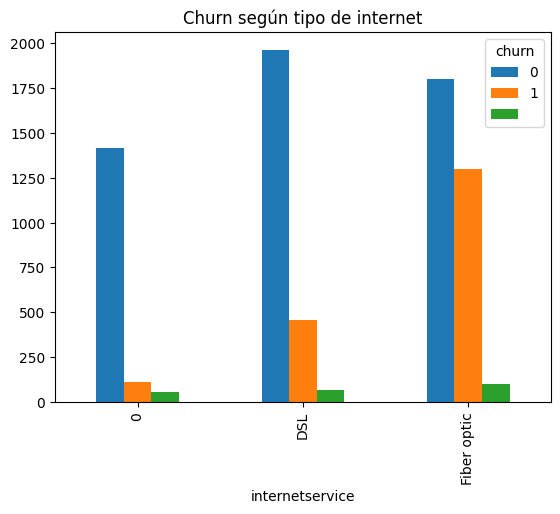

In [12]:
pd.crosstab(df_telecomX['internetservice'], df_telecomX['churn'], normalize='index')*100

pd.crosstab(df_telecomX['internetservice'], df_telecomX['churn']).plot(kind='bar')
plt.title("Churn según tipo de internet")
plt.show()

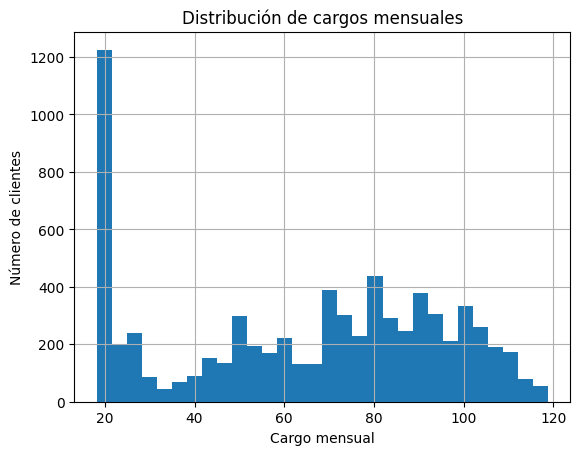

In [13]:
df_telecomX['charges.monthly'].hist(bins=30)

plt.title("Distribución de cargos mensuales")
plt.xlabel("Cargo mensual")
plt.ylabel("Número de clientes")

plt.show()

In [14]:
#Cargos Mensuales

df_telecomX.groupby('churn')['charges.monthly'].mean()

,charges.monthly
churn,
0,61.265124
1,74.441332
,63.412277


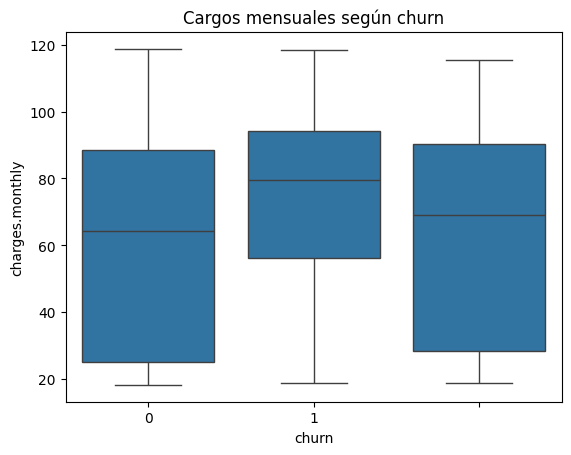

In [15]:
#Cargos Mensuales

df_telecomX.groupby('churn')['charges.monthly'].mean()
sns.boxplot(x='churn', y='charges.monthly', data=df_telecomX)

plt.title("Cargos mensuales según churn")

plt.show()

**Conteo de evasión por variables numéricas**

In [16]:
pd.crosstab(df_telecomX['paymentmethod'], df_telecomX['churn'], normalize='index')*100


churn,0,1,
paymentmethod,,,
Bank transfer (automatic),80.931403,16.236627,2.831970
Credit card (automatic),82.270408,14.795918,2.933673
Electronic check,52.924335,43.803681,3.271984
Mailed check,78.318318,18.498498,3.183183


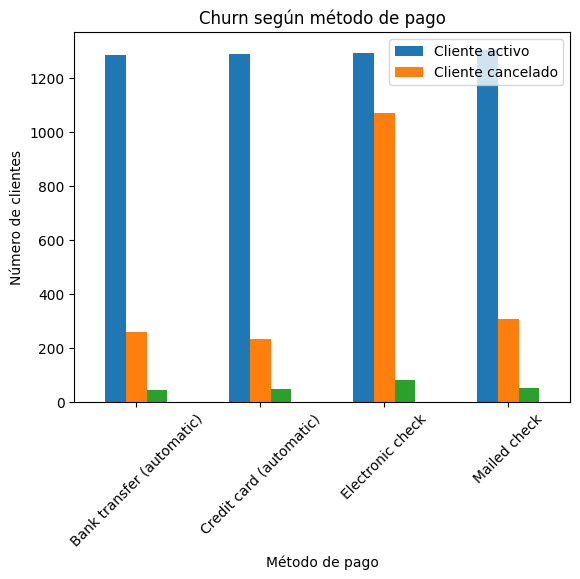

In [17]:
tabla_pago = pd.crosstab(
    df_telecomX['paymentmethod'],
    df_telecomX['churn']
)

tabla_pago.plot(kind='bar')

import matplotlib.pyplot as plt

plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de clientes")

plt.xticks(rotation=45)

plt.legend(['Cliente activo','Cliente cancelado'])

plt.show()

In [18]:
df_telecomX['charges.total'] = pd.to_numeric(df_telecomX['charges.total'], errors='coerce')
df_telecomX.groupby('churn')[['tenure','charges.monthly','charges.total']].mean()

,tenure,charges.monthly,charges.total
churn,,,
0,37.569965,61.265124,2555.344141
1,17.979133,74.441332,1531.796094
,31.571429,63.412277,2196.933705


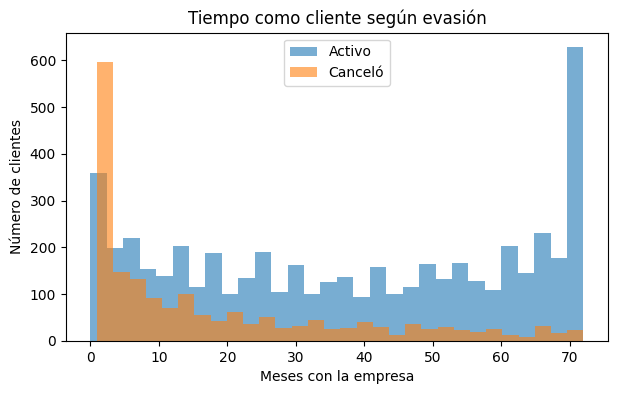

In [19]:
plt.figure(figsize=(7,4))

plt.hist(df_telecomX[df_telecomX['churn']==0]['tenure'], bins=30, alpha=0.6, label='Activo')
plt.hist(df_telecomX[df_telecomX['churn']==1]['tenure'], bins=30, alpha=0.6, label='Canceló')

plt.title("Tiempo como cliente según evasión")
plt.xlabel("Meses con la empresa")
plt.ylabel("Número de clientes")

plt.legend()
plt.show()

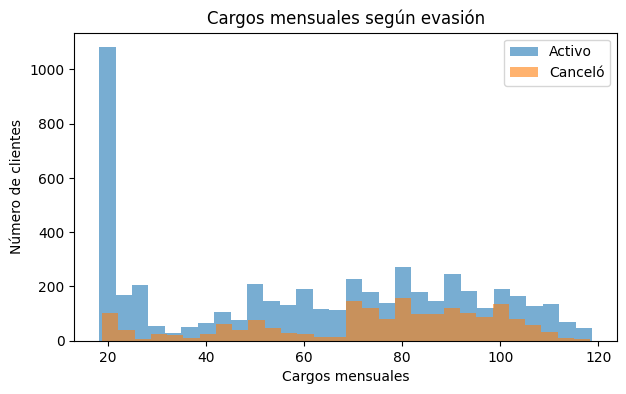

In [20]:
plt.figure(figsize=(7,4))

plt.hist(df_telecomX[df_telecomX['churn']==0]['charges.monthly'], bins=30, alpha=0.6, label='Activo')
plt.hist(df_telecomX[df_telecomX['churn']==1]['charges.monthly'], bins=30, alpha=0.6, label='Canceló')

plt.title("Cargos mensuales según evasión")
plt.xlabel("Cargos mensuales")
plt.ylabel("Número de clientes")

plt.legend()
plt.show()

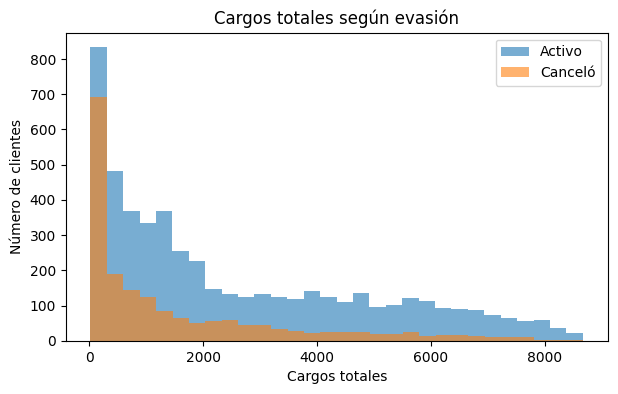

In [21]:
plt.figure(figsize=(7,4))

plt.hist(df_telecomX[df_telecomX['churn']==0]['charges.total'], bins=30, alpha=0.6, label='Activo')
plt.hist(df_telecomX[df_telecomX['churn']==1]['charges.total'], bins=30, alpha=0.6, label='Canceló')

plt.title("Cargos totales según evasión")
plt.xlabel("Cargos totales")
plt.ylabel("Número de clientes")

plt.legend()
plt.show()

### Interpretación del análisis

---


**Tiempo de permanencia (Tenure)**

Se observa que los clientes que cancelan el servicio suelen tener menos tiempo en la empresa, lo que sugiere que la evasión ocurre con mayor frecuencia en los primeros meses de contrato.

**Cargos mensuales**

Los clientes con cargos mensuales más altos presentan mayor probabilidad de cancelar el servicio.

**Cargos totales**

#####Los clientes que permanecen más tiempo en la empresa acumulan mayores cargos totales, lo que refleja mayor permanencia y compromiso con el servicio.